# Surrogate Modelling on BESOS

Surrogate modelling or metamodelling is a way to emulate physics-based building simulation models [[1]].

BESOS integrates building simulation and surrogate modelling using:
+ EnergyPlus model editing and execution via EPPy using [Evaluators](../Evaluators/Evaluators.ipynb)
+ [sampling toolboxes](https://pythonhosted.org/pyDOE/)
+ machine learning toolboxes like [ScikitLearn](https://scikit-learn.org/stable/) and [TensorFlow](https://www.tensorflow.org/)
+ the `besos` module to simplify the interconnection of the above items.

[1]: https://www.sciencedirect.com/science/article/pii/S0378778819302877

## Surrogate Modelling workflow

The figure below shows a BESOS workflow that covers all the elements needed to derive surrogate models.
This is supported by access to powerful hardware for conducting sampling and model training quickly in parallel.

<img src="image/besos_surrogate_overview.png" alt="BESOS for Surrogate Modelling"
title="BESOS for Surrogate Modelling" width="800" />

_BESOS workflow for Surrogate Modelling [[1]]._

[1]: https://www.sciencedirect.com/science/article/pii/S0378778819302877.

# Surrogate Modelling Work Flow

+ define a problem consisting of parameters to vary with ranges and an objective function
+ sample the problem space
+ define an Evaluator by linking the problem to an EnergyPlus model
+ run the Evaluator for the samples
+ train a surrogate model over the samples
+ explore the design space using an interactive plot that queries the surrogate model

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from besos import eppy_funcs as ef, sampling
from besos.evaluator import EvaluatorEP,EvaluatorGeneric
from besos.parameters import FieldSelector, Parameter, RangeParameter, expand_plist,wwr, FilterSelector, CategoryParameter, GenericSelector,expand_plist 
from besos.problem import EPProblem
from ipywidgets import FloatSlider, interact
from matplotlib import pyplot as plt
from sklearn import linear_model, pipeline
from sklearn.preprocessing import StandardScaler
%matplotlib notebook

## Building model
We load an EnergyPlus model.

In [2]:
building = ef.get_building('test.idf')
building.idfobjects

{'VERSION': [
 Version,
     9.6;                      !- Version Identifier
 ],
 'SIMULATIONCONTROL': [
 SimulationControl,
     Yes,                      !- Do Zone Sizing Calculation
     Yes,                      !- Do System Sizing Calculation
     No,                       !- Do Plant Sizing Calculation
     No,                       !- Run Simulation for Sizing Periods
     Yes,                      !- Run Simulation for Weather File Run Periods
     No,                       !- Do HVAC Sizing Simulation for Sizing Periods
     1;                        !- Maximum Number of HVAC Sizing Simulation Passes
 ],
 'PERFORMANCEPRECISIONTRADEOFFS': [],
 'BUILDING': [
 Building,
     Building,                 !- Name
     0,                        !- North Axis
     Suburbs,                  !- Terrain
     0.04,                     !- Loads Convergence Tolerance Value
     0.4,                      !- Temperature Convergence Tolerance Value
     FullExterior,             !- Solar Distri

## Parameters and Objectives
We start by defining `Parameters` that govern how we would like to modify the building.
Here they are the solar heat gain coefficient and the lighting power density.

In [3]:
parameters = []
parameters = expand_plist(
    {"XPS Extruded Polystyrene  - CO2 Blowing_0041": {"Thickness": (0.001, 0.3)},

    }  # Name from IDF Building object,
)

parameters.append(
    wwr(RangeParameter(0.1, 0.9))
)  # Add window-to-wall ratio as a parameter between 0.1 and 0.9 using a custom function

Now, we specify that we would like to optimize for electricity use of the entire facility. We then bundle all of this information together.

In [4]:
objectives = ["DistrictHeating:Facility"]
problem = EPProblem(parameters, objectives)

## Sampling

We need to generate samples on which to train a surrogate model.
The `sampler` uses Latin Hypercube Sampling to distribute the samples in the design space defined by the `Parameters`.
We can check how well distributed they are using `describe()`.

In [5]:
inputs = sampling.dist_sampler(sampling.lhs, problem, 10)
inputs

,Thickness,"RangeParameter [0.1, 0.9]"
0,0.107364,0.429849
1,0.203964,0.845666
2,0.134921,0.117514
3,0.037738,0.693476
4,0.225777,0.308592
5,0.243834,0.621568
6,0.173625,0.190034
7,0.273182,0.805280
8,0.007547,0.523881
9,0.080341,0.340651


## Evaluator
We now define and run the Evaluator, which will run the EnergyPlus instances with the different inputs generated in the previous cell.

In [6]:
import time

In [7]:
evaluator = EvaluatorEP(problem, building)
t1 = time.time()
train = evaluator.df_apply(inputs, keep_input=True,processes=4)

t2 = time.time()
train.head()  # first 5 lines

EnergyPlus Starting
EnergyPlus Starting
EnergyPlus, Version 9.6.0-f420c06a69, YMD=2024.11.19 13:34
EnergyPlus, Version 9.6.0-f420c06a69, YMD=2024.11.19 13:34
EnergyPlus Starting
EnergyPlus, Version 9.6.0-f420c06a69, YMD=2024.11.19 13:34
EnergyPlus Starting
EnergyPlus, Version 9.6.0-f420c06a69, YMD=2024.11.19 13:34


Could not find platform independent libraries <prefix>
Could not find platform independent libraries <prefix>
Could not find platform independent libraries <prefix>
Could not find platform dependent libraries <exec_prefix>
Consider setting $PYTHONHOME to <prefix>[:<exec_prefix>]
Could not find platform dependent libraries <exec_prefix>
Consider setting $PYTHONHOME to <prefix>[:<exec_prefix>]
Could not find platform dependent libraries <exec_prefix>
Consider setting $PYTHONHOME to <prefix>[:<exec_prefix>]
Could not find platform independent libraries <prefix>
Could not find platform dependent libraries <exec_prefix>
Consider setting $PYTHONHOME to <prefix>[:<exec_prefix>]


Initializing Response Factors
Initializing Response Factors
Initializing Response Factors
Initializing Response Factors
Calculating CTFs for "PROJECT GROUND FLOOR"
Calculating CTFs for "PROJECT GROUND FLOOR"
Calculating CTFs for "PROJECT GROUND FLOOR"
Calculating CTFs for "PROJECT GROUND FLOOR"
Calculating CTFs for "PROJECT FLAT ROOF"
Calculating CTFs for "PROJECT FLAT ROOF"
Calculating CTFs for "PROJECT FLAT ROOF"
Calculating CTFs for "PROJECT FLAT ROOF"
Calculating CTFs for "PROJECT PARTITION"
Calculating CTFs for "PROJECT PARTITION"
Calculating CTFs for "PROJECT PARTITION"
Calculating CTFs for "PROJECT PARTITION"
Calculating CTFs for "PROJECT PARTITION_REV"
Calculating CTFs for "PROJECT PARTITION_REV"
Calculating CTFs for "PROJECT PARTITION_REV"
Calculating CTFs for "PROJECT PARTITION_REV"
Calculating CTFs for "PROJECT WALL"
Calculating CTFs for "PROJECT WALL"
Calculating CTFs for "PROJECT WALL"
Calculating CTFs for "PROJECT WALL"
Initializing Window Optical Properties
Initializing 

Updating Shadowing Calculations, Start Date=01/21/2017
Continuing Simulation at 01/21/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=01/21/2017
Continuing Simulation at 01/21/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=01/21/2017
Continuing Simulation at 01/21/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=01/21/2017
Continuing Simulation at 01/21/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=02/10/2017
Updating Shadowing Calculations, Start Date=02/10/2017
Continuing Simulation at 02/10/2017 for UNTITLED (01-01:31-12)
Continuing Simulation at 02/10/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=02/10/2017
Continuing Simulation at 02/10/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=02/10/2017
Continuing Simulation at 02/10/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=03/02/2017
C

EnergyPlus Completed Successfully.


...

Initializing Response Factors
Calculating CTFs for "PROJECT GROUND FLOOR"
Calculating CTFs for "PROJECT FLAT ROOF"
Calculating CTFs for "PROJECT PARTITION"
Calculating CTFs for "PROJECT PARTITION_REV"
Calculating CTFs for "PROJECT WALL"
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module Arrays
Initializing Zone and Enclosure Report Variables
Initializing Surface (Shading) Report Variables
Computing Interior Solar Absorption Factors
Determining Shadowing Combinations
Updating Shadowing Calculations, Start Date=10/28/2017
Computing Window Shade Absorption Factors
Proceeding with Initializing Solar Calculations
Initializing Surfaces
Initializing Outdoor environment for Surfaces
Setting up Surface Reporting Variables
Initializing Temperature and Flux Histories
Initializing Window Shading
Computing Interior Absorption Factors
Computing Interior Diffuse Solar Absorption Factors
Initializing Solar Heat Gains
Initializing Internal Heat Gains
Initializi

EnergyPlus Completed Successfully.


Updating Shadowing Calculations, Start Date=02/10/2017
Continuing Simulation at 02/10/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=03/02/2017
Continuing Simulation at 03/02/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=03/22/2017
Continuing Simulation at 03/22/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=04/11/2017
Continuing Simulation at 04/11/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=05/01/2017
Continuing Simulation at 05/01/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=05/21/2017
Continuing Simulation at 05/21/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=06/10/2017
Continuing Simulation at 06/10/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=06/30/2017
Continuing Simulation at 06/30/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=07/20/2017
C

EnergyPlus Completed Successfully.


,Thickness,"RangeParameter [0.1, 0.9]",DistrictHeating:Facility
0,0.107364,0.429849,5.949072e+10
1,0.203964,0.845666,5.705979e+10
2,0.134921,0.117514,5.710140e+10
3,0.037738,0.693476,7.013669e+10
4,0.225777,0.308592,5.507424e+10


In [8]:
def niceformat(seconds):
    seconds = seconds % (24 * 3600)
    hour = seconds // 3600
    seconds %= 3600
    minutes = seconds // 60
    seconds %= 60
    return hour, minutes, seconds




In [9]:
time_of_sim = t2 - t1
hours, mins, secs = niceformat(time_of_sim)

print(
    "The total running time: {:2.0f} hours {:2.0f} min {:2.0f} seconds".format(
        hours, mins, secs
    )
)
# Build a results DataFrame

The total running time:  0 hours  3 min 35 seconds


We can save results at this point:

In [10]:
train.to_pickle("samples.p")

And load them again later:

In [11]:
train = pd.read_pickle("samples.p")

## Exploring the training data
Let's look at the correlation amongst the inputs and the output using a built-in [Seaborn](http://seaborn.pydata.org/) plot:

<IPython.core.display.Javascript object>


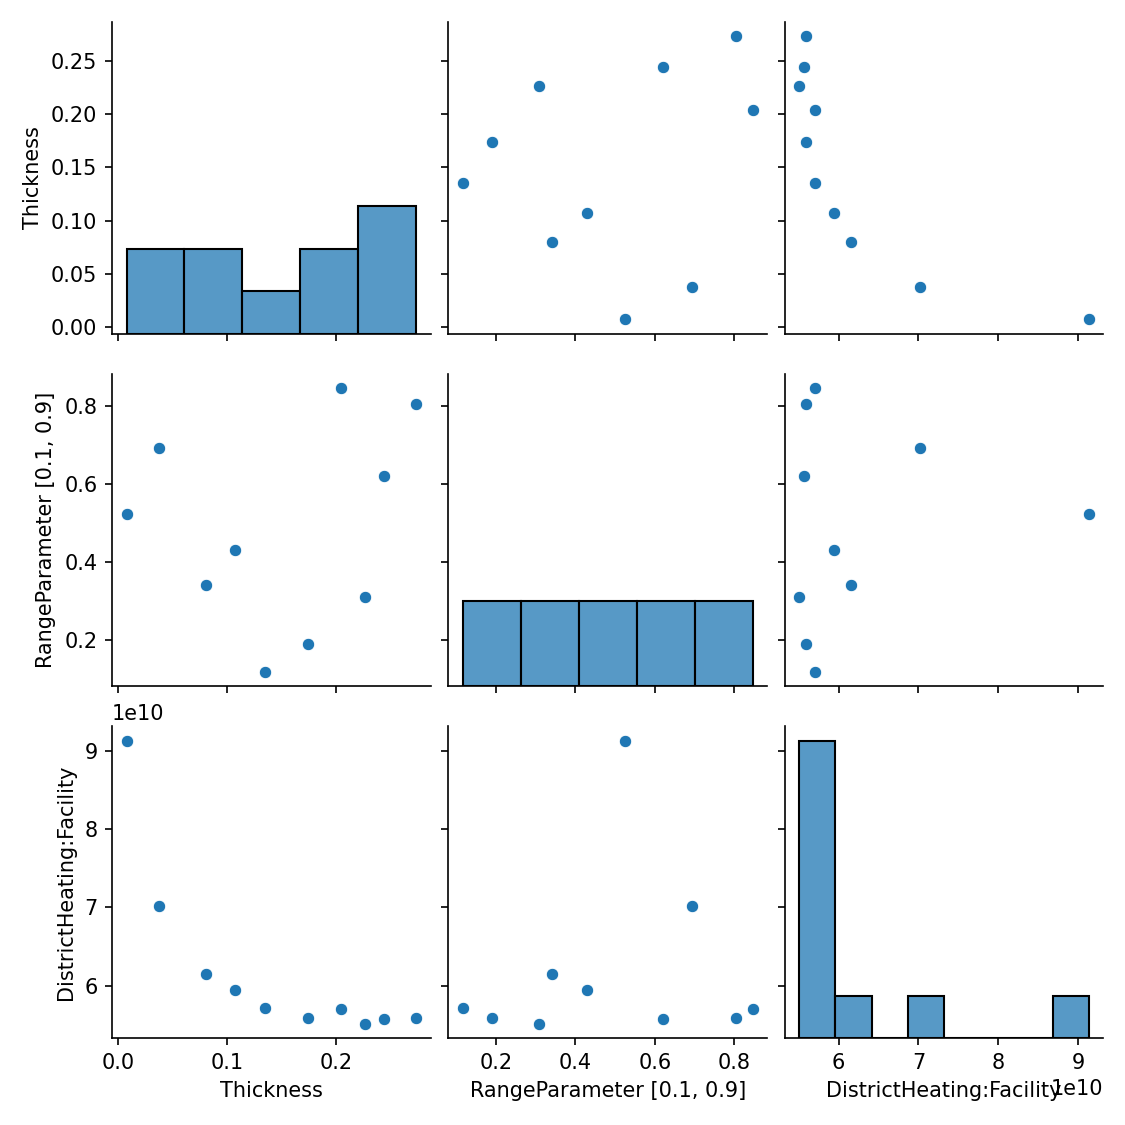

In [12]:
g = sns.pairplot(train)

Here's a plot of the _design space_ defined by the samples.

<IPython.core.display.Javascript object>


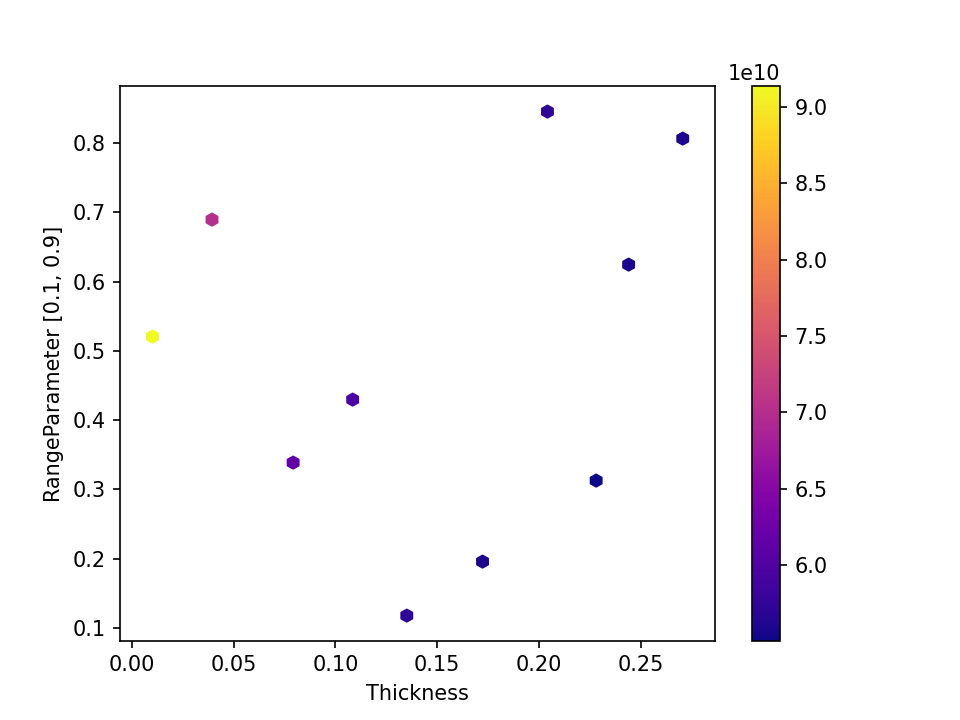

In [13]:
x, y,obj = problem.names()
train.plot.hexbin(x=x, y=y, C=obj, cmap="plasma", sharex=False, gridsize=50)

In [14]:
problem.names()

['Thickness', 'RangeParameter [0.1, 0.9]', 'DistrictHeating:Facility']

## Fitting a surrogate model

Now we can train the model using a ScikitLearn pipeline:

In [15]:
train

,Thickness,"RangeParameter [0.1, 0.9]",DistrictHeating:Facility
0,0.107364,0.429849,5.949072e+10
1,0.203964,0.845666,5.705979e+10
2,0.134921,0.117514,5.710140e+10
3,0.037738,0.693476,7.013669e+10
4,0.225777,0.308592,5.507424e+10
5,0.243834,0.621568,5.572091e+10
6,0.173625,0.190034,5.590923e+10
7,0.273182,0.805280,5.588206e+10
8,0.007547,0.523881,9.131781e+10
9,0.080341,0.340651,6.154573e+10


In [16]:
model = pipeline.make_pipeline(StandardScaler(), linear_model.LinearRegression())
model.fit(train[[x, y]].values, train[obj].values)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])

## Running the surrogate model

We can query the model at a specific point in the design space:

In [17]:
model.predict([[0.2, 0.25]])

array([5.34155951e+10])

Or for a `dataframe` made from a `dictionary` of points:

In [18]:
points = pd.DataFrame(data={"Thikness": [0, 1], "WWR": [8, 12]})
model.predict(points)

/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:443: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


array([1.76160258e+11, 1.23297224e+11])

Next we define a function for querying the surrogate model across the domain at a given density, and plot the result.

/tmp/ipykernel_148/4061485770.py:2: DeprecationWarning: Call to deprecated function (or staticmethod) inputs. (Problem.inputs is ambiguous, use .value_descriptors or .parameters instead.) -- Deprecated since version 2.0.
  p1 = problem.inputs[0].value_descriptor
/tmp/ipykernel_148/4061485770.py:2: DeprecationWarning: Call to deprecated function (or staticmethod) value_descriptor. (Does not support multiple Descriptors per Parameter.Use the value_descriptors of this Parameter instead.) -- Deprecated since version 2.0.0.
  p1 = problem.inputs[0].value_descriptor
/tmp/ipykernel_148/4061485770.py:4: DeprecationWarning: Call to deprecated function (or staticmethod) inputs. (Problem.inputs is ambiguous, use .value_descriptors or .parameters instead.) -- Deprecated since version 2.0.
  p2 = problem.inputs[1].value_descriptor
/tmp/ipykernel_148/4061485770.py:4: DeprecationWarning: Call to deprecated function (or staticmethod) value_descriptor. (Does not support multiple Descriptors per Paramet

<IPython.core.display.Javascript object>


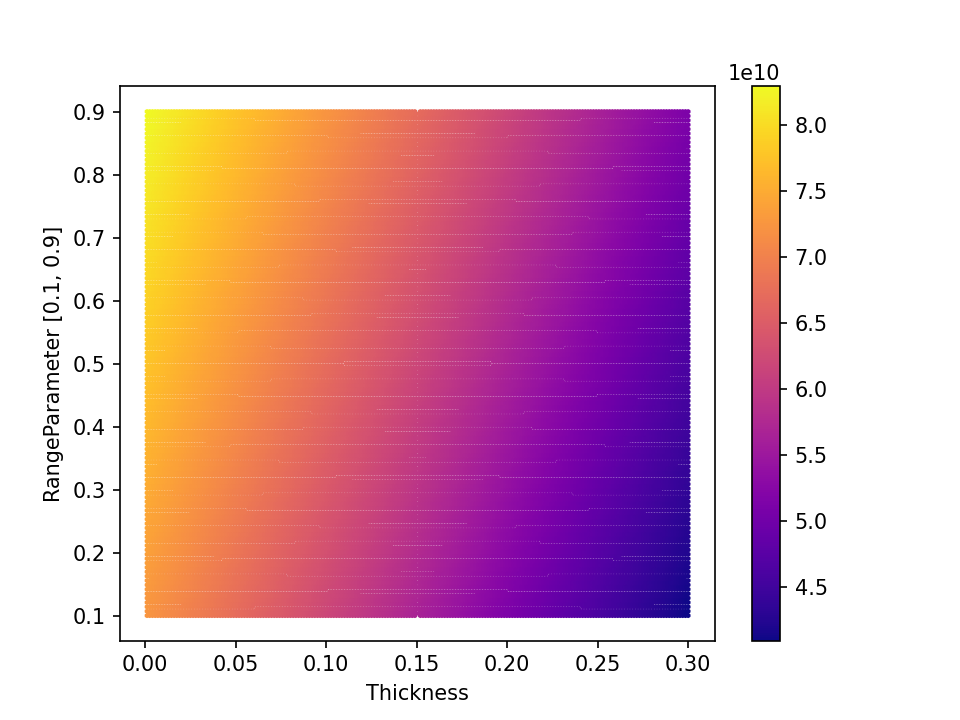

In [19]:
def run_model(model, density):
    p1 = problem.inputs[0].value_descriptor
    a = np.linspace(p1.min, p1.max, density)
    p2 = problem.inputs[1].value_descriptor
    b = np.linspace(p2.min, p2.max, density)
    plot_data = pd.DataFrame(
        np.transpose([np.tile(a, len(b)), np.repeat(b, len(a))]),
        columns=problem.names("inputs"),
    )
    return pd.concat([plot_data, pd.Series(model.predict(plot_data))], axis=1)


density = 200
df = run_model(model, density)
df.plot.hexbin(x=x, y=y, C=0, cmap="plasma", gridsize=density, sharex=False)

## Interactive surrogate
We make an interactive plot using `ipywidgets`, which executes the model every time a slider is moved.

In [20]:
# get the min and max of the two variables
(min1, max1), (min2, max2) = (
    (float(p.value_descriptor.min), p.value_descriptor.max) for p in problem.inputs
)
# get the data to plot in the background
df = run_model(model, 100)

# define a wrapper to be queried by interact
def model_wrapper(v1, v2):
    df.plot.hexbin(
        x=x, y=y, C=0, cmap="plasma", gridsize=30, sharex=False
    )  # background plot
    x_lims = plt.xlim()
    y_lims = plt.ylim()
    plt.scatter(x=v1, y=v2)  # plot the marker
    plt.xlim((x_lims))
    plt.ylim((y_lims))

    value = (
        model.predict([[v1, v2]])[0] / 3.6e6
    )  # find the current value and convert to kWh
    output = (
        "Heating use = " + str(value.round()) + " kWh"
    )  # return the string to display
    return output


# make the interactive plot with two sliders
continuous_update = False
interact(
    model_wrapper,
    v1=FloatSlider(
        min=min1,
        max=max1,
        value=(min1 + max1) / 2,
        description="Thikness [m]",
        step=0.01,
        continuous_update=continuous_update,
    ),
    v2=FloatSlider(
        min=min2,
        max=max2,
        value=(min2 + max2) / 2,
        description="WWR",
        continuous_update=continuous_update,
    ),
)

/tmp/ipykernel_148/1546830596.py:3: DeprecationWarning: Call to deprecated function (or staticmethod) inputs. (Problem.inputs is ambiguous, use .value_descriptors or .parameters instead.) -- Deprecated since version 2.0.
  (float(p.value_descriptor.min), p.value_descriptor.max) for p in problem.inputs
/tmp/ipykernel_148/1546830596.py:3: DeprecationWarning: Call to deprecated function (or staticmethod) value_descriptor. (Does not support multiple Descriptors per Parameter.Use the value_descriptors of this Parameter instead.) -- Deprecated since version 2.0.0.
  (float(p.value_descriptor.min), p.value_descriptor.max) for p in problem.inputs
/tmp/ipykernel_148/4061485770.py:2: DeprecationWarning: Call to deprecated function (or staticmethod) inputs. (Problem.inputs is ambiguous, use .value_descriptors or .parameters instead.) -- Deprecated since version 2.0.
  p1 = problem.inputs[0].value_descriptor
/tmp/ipykernel_148/4061485770.py:2: DeprecationWarning: Call to deprecated function (or st

interactive(children=(FloatSlider(value=0.1505, continuous_update=False, description='Thikness [m]', max=0.3, …

<function __main__.model_wrapper(v1, v2)>

# GP vs Nural Network vs TF

Lets compare now a Gaussian Process with a Neural Network and a TensorFlow for surrogate model creation. On a more complex design space.

In [21]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import warnings

In [22]:
insulation = FieldSelector(class_name='Material', object_name='XPS Extruded Polystyrene  - CO2 Blowing_0041', field_name='Thickness')
insulation_range = RangeParameter(min_val = 0.01, max_val=0.45)
insulation_param = Parameter(selector=insulation,
                                 value_descriptors=insulation_range,
                                 name='Insulation Thickness')


In [23]:
lights_selector = FieldSelector(class_name='Lights', object_name='*', field_name='Watts per Zone Floor Area')
single_digit_integers = CategoryParameter(options=range(8,13))
lights_param =     Parameter(
        lights_selector,
        value_descriptors=single_digit_integers ,
        name="Lights Watts/Area",
    )

In [24]:
# class_name is NOT provided
#{'object_name':
# {'field_name':(min, max)}}
more_parameters = expand_plist(
    {
        #"Building":
        #{
        #    "North Axis":(0,359)
        #},
        "3":
         {
             'Conductivity':(0.1,1),
             'Solar Transmittance at Normal Incidence':(0.01,0.8)
         }
    })

In [25]:
window_to_wall = wwr(RangeParameter(0.1,0.9))

In [26]:
parameters = [insulation_param] + more_parameters +[window_to_wall] + [lights_param]

In [27]:
objectives = ['Electricity:Facility','DistrictHeating:Facility','DistrictCooling:Facility'] # these get made into `MeterReader` or `VariableReader`

problem=EPProblem(parameters, objectives) # problem = parameters + objectives



In [28]:
samples = sampling.dist_sampler(sampling.lhs, problem, num_samples=20)
samples

,Insulation Thickness,Conductivity,Solar Transmittance at Normal Incidence,"RangeParameter [0.1, 0.9]",Lights Watts/Area
0,0.429101,0.704555,0.620055,0.446013,9
1,0.278709,0.277958,0.181425,0.849236,10
2,0.223287,0.339790,0.389841,0.174704,12
3,0.271318,0.985655,0.339876,0.515829,8
4,0.106250,0.170988,0.237167,0.868459,9
5,0.154612,0.428692,0.567352,0.549888,9
6,0.092090,0.757315,0.422418,0.491551,10
7,0.138247,0.911156,0.459519,0.269476,11
8,0.197230,0.674605,0.504089,0.780276,11
9,0.309757,0.588046,0.110540,0.752255,9


In [29]:
evaluator = EvaluatorEP(problem, 
                        building, 
                        out_dir='outputdir', 
                        err_dir='outputdir',
                        epw_file='ITA_Torino.160590_IWEC.epw',
                        progress_bar=True)
try:
    
    sim_samples=pd.read_csv('surrogate_simple_simulation.csv',index_col=0)

    # Build a results DataFrame
except: 
    t1 = time.time()
    sim_samples = evaluator.df_apply(samples,
                             keep_input=True, 
                             #keep_dirs=True, 
                             processes=4)  # flag keep_dirs to True to save all ouput
    t2 = time.time()
    time_of_sim = t2 - t1
    hours, mins, secs = niceformat(time_of_sim)

    print(
        "The total running time: {:2.0f} hours {:2.0f} min {:2.0f} seconds".format(
            hours, mins, secs
        )
    )
    sim_samples.to_csv('surrogate_simple_simulation.csv')


/opt/conda/envs/design/lib/python3.9/site-packages/besos/evaluator.py:672: FutureWarning: epw_file has been deprecated and will be removed in the future. Use epw instead.
  warn(


In [30]:
sim_samples.columns

Index(['Insulation Thickness', 'Conductivity',
       'Solar Transmittance at Normal Incidence', 'RangeParameter [0.1, 0.9]',
       'Lights Watts/Area', 'Electricity:Facility', 'DistrictHeating:Facility',
       'DistrictCooling:Facility'],
      dtype='object')

In [31]:
features = list(samples.columns)
print(features)
print(objectives)

['Insulation Thickness', 'Conductivity', 'Solar Transmittance at Normal Incidence', 'RangeParameter [0.1, 0.9]', 'Lights Watts/Area']
['Electricity:Facility', 'DistrictHeating:Facility', 'DistrictCooling:Facility']


In [32]:
#remove inputs
outputs = sim_samples.drop(features, axis=1)
#outputs

In [33]:
#remove outputs and windows types shading
samples = sim_samples.drop(objectives, axis=1)
#samples

## Train-test split

Next we split the data into a training set (80%) and a testing set (20%).

In [34]:
train_in, test_in, train_out, test_out = train_test_split(
    samples, outputs, test_size=0.2
)

## Normalization of inputs

To ensure an equal weighting of inputs and outputs in the backpropagation algorithm fitting the neural network, we have to normalize the input values.
For example window-to-wall ratio is in the range of 0 to 1 while the $W/$m^2$ are in a range of 10 to 15.
Different options for normalization exist.
Here we bring all features (input variables) to have zero mean and a standarddeviation of 1.
Note that we fit the normalizer on training data only.

In [35]:
scaler = StandardScaler()
train_in_scale = scaler.fit_transform(X=train_in)
test_in_scale = scaler.fit_transform(X=test_in)

scaler_out = StandardScaler()
train_out_scale = scaler_out.fit_transform(X=train_out)
test_out_scale = scaler_out.fit_transform(X=test_out)

# Gaussian Process


## Hyper-parameters

Before fitting the GP model we define the set of hyperparameters we want to optimize.
Here we use \textit{3} folds in the k-fold cross validation scheme.
We select a set of Kernel functions, which must fit the characteristics of a problem - details and examples may be found in the [Kernel cookbook](https://www.cs.toronto.edu/~duvenaud/cookbook/).
Note that the parameters of the Kernel itself are [optimized during each model fitting run](https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.GaussianProcessRegressor.html).

In [36]:
hyperparameters = {
    "kernel": [
        None,
        1.0 * RBF(length_scale=1.0, length_scale_bounds=(1e-1, 10.0)),
        1.0 * RationalQuadratic(length_scale=1.0, alpha=0.5),
        # ConstantKernel(0.1, (0.01, 10.0))*(DotProduct(sigma_0=1.0, sigma_0_bounds=(0.1, 10.0))**2),
        1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-1, 10.0)),
    ]
}

folds = 3

## Model fitting

Here we fit the model using these hyperparameters.

In [37]:
gp = GaussianProcessRegressor(normalize_y=True)

clf = GridSearchCV(gp, hyperparameters, cv=folds)

clf.fit(train_in_scale, train_out_scale)

best_gp = clf.best_estimator_ 

/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:616: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/conda/envs/design/

In [38]:
prediction_gp = scaler_out.inverse_transform(best_gp.predict(test_in_scale))

# Neural Network

## Hyper-parameters

Before we start fitting the NN model we define the set of hyperparameters we want to analyse in our cross-validation to optimize the model.
Here, we select the number of layers of the network as well as the regularization parameter alpha as parameter value.
A larger number of layers and a lower value of the regularizer lead to higher variance of the network.
This may lead to overfitting.
The best selection may be found using an optimizer like Bayesian Optimization.
In this example we use a simple grid search.

In [39]:
hyperparameters = {
    "hidden_layer_sizes": (
        (len(parameters) * 16,),
        (len(parameters) * 16, len(parameters) * 16),
    ),
    "alpha": [1, 10, 10 ** 3],
}

neural_net = MLPRegressor(max_iter=1000, early_stopping=False)
folds = 3

## Model fitting

Here, we use the NN model from ScikitLearn.


In [40]:
clf = GridSearchCV(neural_net, hyperparameters, cv=folds)
clf.fit(train_in_scale, train_out_scale)

nn_model = clf.best_estimator_

In [41]:
prediction_nn = scaler_out.inverse_transform(nn_model.predict(test_in_scale))

In [42]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2024-11-19 13:38:34.783203: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2024-11-19 13:38:34.783247: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


Couldn't import dot_parser, loading of dot files will not be possible.


In [43]:
def build_model():
    model = keras.Sequential(
        [
            layers.Input(shape=(train_in_scale.shape[1], )),
            layers.Dense(32, activation='relu'),
            layers.Dense(64, activation='relu'),
            layers.Dense(32, activation='relu'),
            layers.Dense(3),
        ]
    )

    optimizer = tf.keras.optimizers.Adam(0.001)

    model.compile(loss="mse", optimizer=optimizer, metrics=["mae", "mse"])
    return model

model = build_model()

model.summary()

EPOCHS = 1000

history = model.fit(
    train_in_scale,
    train_out_scale,
    epochs=EPOCHS,
    validation_split=0.2,
    verbose=0,
)

2024-11-19 13:38:46.494701: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2024-11-19 13:38:46.494742: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2024-11-19 13:38:46.494802: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (610e595e5415): /proc/driver/nvidia/version does not exist
2024-11-19 13:38:46.496741: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                192       
                                                                 
 dense_1 (Dense)             (None, 64)                2112      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 3)                 99        
                                                                 
Total params: 4,483
Trainable params: 4,483
Non-trainable params: 0
_________________________________________________________________


In [44]:
prediction_tf = scaler_out.inverse_transform(model.predict(test_in_scale))

In [45]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from math import sqrt


In [46]:
mean_squared_error(prediction_gp,test_out.values,multioutput='raw_values',squared=False)/test_out.mean()*100

Electricity:Facility        0.049428
DistrictHeating:Facility    3.364048
DistrictCooling:Facility    0.925629
dtype: float64

In [47]:
mean_squared_error(prediction_nn,test_out.values,multioutput='raw_values',squared=False)/test_out.mean()*100

Electricity:Facility        0.527995
DistrictHeating:Facility    2.726084
DistrictCooling:Facility    1.702919
dtype: float64

In [48]:
mean_squared_error(prediction_tf,test_out.values,multioutput='raw_values',squared=False)/test_out.mean()*100

Electricity:Facility        2.230671
DistrictHeating:Facility    4.670169
DistrictCooling:Facility    2.919659
dtype: float64

## Surrogate Modelling Evaluator object
We can wrap the fitted model in a BESOS `Evaluator`.

In [49]:
#definition of the evaluation function
def evaluation_func(ind, scaler=scaler):
    ind = scaler.transform(X=[ind])
    return (scaler_out.inverse_transform(nn_model.predict(ind))[0]).tolist()
evaluator = EvaluatorGeneric(evaluation_func, problem)


In [50]:
srinputs = sampling.dist_sampler(sampling.lhs, problem, 500)
sroutputs = evaluator.df_apply(srinputs)
srresults = srinputs.join(sroutputs)
srresults.head()

Executing:   0%|          | 0/500 [00:00<?, ?row/s]

/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/b

/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/b

/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/b

,Insulation Thickness,Conductivity,Solar Transmittance at Normal Incidence,"RangeParameter [0.1, 0.9]",Lights Watts/Area,Electricity:Facility,DistrictHeating:Facility,DistrictCooling:Facility
0,0.190648,0.672624,0.343936,0.699517,10,6.022595e+10,4.523672e+10,3.204922e+10
1,0.408900,0.750184,0.345242,0.499008,12,6.487862e+10,4.115168e+10,3.239637e+10
2,0.238183,0.239347,0.366557,0.858573,11,6.256693e+10,4.324293e+10,3.303114e+10
3,0.049085,0.274146,0.108825,0.719834,11,6.251541e+10,4.761201e+10,3.358685e+10
4,0.121439,0.485106,0.081388,0.861360,9,5.821404e+10,4.649064e+10,3.123675e+10


## Exploration

In [51]:
import plotly
plotly.offline.init_notebook_mode(connected=True)

In [52]:
import plotly.express as px
fig = px.parallel_coordinates(srresults,color="Electricity:Facility", dimensions=features+objectives,
                             color_continuous_scale=px.colors.diverging.Tealrose)
fig.show()

In [53]:
import pickle
pickle.dump(nn_model, open('best_surrogate', 'wb'))